# RoadSafe India — Multivariable Regression

## Objective

This notebook investigates whether State/UT-level vehicle exposure and road
infrastructure are associated with reported road-safety outcomes when
multiple explanatory variables are considered simultaneously.

## Available Sample

The road-infrastructure analysis contains 35 complete State/UT observations
because the available 2019 infrastructure source does not provide a separate
Ladakh observation.

## Primary Outcomes

- Reported accidents in 2024
- Reported fatalities in 2024

## Candidate Predictors

- Population
- Vehicle registrations
- Road length

## Methodological Approach

The first stage evaluates predictor distributions, pairwise correlations and
multicollinearity before fitting regression models.

Because the number of State/UT observations is small, the initial models
will contain a limited number of predictors and will be treated as
exploratory rather than definitive causal models.

## Research Questions

1. Are vehicle registrations associated with reported accident burden after
   accounting for road infrastructure?

2. Are vehicle registrations associated with reported fatality burden after
   accounting for road infrastructure?

3. Does road infrastructure provide additional explanatory value after
   accounting for vehicle exposure?

## Outcomes

- Reported accidents per 100,000 population
- Reported fatalities per 100,000 population

## Predictors

- Vehicles per 1,000 population
- Road length per 1,000 population

## Study Sample

The regression analysis uses State/UT observations for which both vehicle
exposure and road infrastructure data are available.

The available 2019 road infrastructure source does not provide a separate
road-length observation for Ladakh, resulting in 35 complete observations.

## Important Interpretation

The analysis is observational and State/UT-level. Regression coefficients
represent conditional associations and should not be interpreted as causal
effects.

Road length is measured in 2019, whereas accident, fatality and vehicle
registration outcomes are from 2024. Therefore, the infrastructure variable
represents a lagged structural characteristic.

In [49]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence
)

from statsmodels.stats.diagnostic import (
    het_breuschpagan
)

In [50]:
# Project paths

project_root = Path.cwd().parent

print("Project root:")
print(project_root)

Project root:
d:\Data Science\Projects\RoadSafe-India


In [51]:
# Load research dataset

research_path = (
    project_root
    / "data"
    / "research"
    / "road_infrastructure_2019_state_level.csv"
)

print("Research dataset path:")
print(research_path)

print("\nFile exists:", research_path.exists())

research_df = pd.read_csv(
    research_path
)

print("\nDataset shape:")
print(research_df.shape)

display(
    research_df.head()
)

Research dataset path:
d:\Data Science\Projects\RoadSafe-India\data\research\road_infrastructure_2019_state_level.csv

File exists: True

Dataset shape:
(36, 30)


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024,vehicle_registrations_2024,vehicles_per_1000_population,road_length_2019_km,road_length_per_1000_population
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,1307.0,18.567978,9.0,8.0,11.0,8.0,911747,17.093120,176351.0,3.306168
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,95.0,130.136986,27.0,27.0,24.0,18.0,36796,23.347716,55262.0,35.064721
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,722.0,27.462914,16.0,18.0,19.0,22.0,629458,17.462147,399122.0,11.072267
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,2648.0,39.528288,14.0,7.0,33.0,25.0,1395212,10.849913,298205.0,2.319001
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,2339.0,50.781589,11.0,11.0,9.0,2.0,714000,23.391430,105074.0,3.442340


In [52]:
# Check required columns

required_columns = [
    "state",
    "2024_accidents",
    "2024_killed",
    "population_2024",
    "vehicle_registrations_2024",
    "road_length_2019_km",
    "accidents_per_100k_population",
    "fatalities_per_100k_population"
]

missing_columns = [
    column
    for column in required_columns
    if column not in research_df.columns
]

print("Missing required columns:")
print(missing_columns)

Missing required columns:
[]


In [53]:
# Create regression analysis sample

regression_df = (
    research_df[
        required_columns
    ]
    .dropna()
    .copy()
)

print(
    "Complete regression observations:",
    len(regression_df)
)

print(
    "Unique States/UTs:",
    regression_df["state"].nunique()
)

print(
    "Duplicate States/UTs:",
    regression_df["state"].duplicated().sum()
)

Complete regression observations: 35
Unique States/UTs: 35
Duplicate States/UTs: 0


In [54]:
# Create normalized predictor variables

regression_df["vehicles_per_1000_population"] = (
    regression_df["vehicle_registrations_2024"]
    / regression_df["population_2024"]
    * 1000
)

regression_df["road_length_per_1000_population"] = (
    regression_df["road_length_2019_km"]
    / regression_df["population_2024"]
    * 1000
)

print("Normalized predictors created.")

display(
    regression_df[
        [
            "state",
            "vehicles_per_1000_population",
            "road_length_per_1000_population"
        ]
    ].head()
)

Normalized predictors created.


,state,vehicles_per_1000_population,road_length_per_1000_population
0,Andhra Pradesh,17.093120,3.306168
1,Arunachal Pradesh,23.347716,35.064721
2,Assam,17.462147,11.072267
3,Bihar,10.849913,2.319001
4,Chhattisgarh,23.391430,3.442340


In [55]:
# Validate normalized predictors

check_columns = [
    "vehicles_per_1000_population",
    "road_length_per_1000_population",
    "accidents_per_100k_population",
    "fatalities_per_100k_population"
]

print("Missing values:")
display(
    regression_df[check_columns].isna().sum()
)

print("\nInfinite values:")
display(
    np.isinf(
        regression_df[check_columns]
    ).sum()
)

Missing values:


vehicles_per_1000_population       0
road_length_per_1000_population    0
accidents_per_100k_population      0
fatalities_per_100k_population     0
dtype: int64


Infinite values:


vehicles_per_1000_population       0
road_length_per_1000_population    0
accidents_per_100k_population      0
fatalities_per_100k_population     0
dtype: int64

In [56]:
# Correlation between normalized predictors

predictor_columns = [
    "vehicles_per_1000_population",
    "road_length_per_1000_population"
]

predictor_corr = (
    regression_df[predictor_columns]
    .corr()
)

display(predictor_corr)

,vehicles_per_1000_population,road_length_per_1000_population
vehicles_per_1000_population,1.000000,-0.080747
road_length_per_1000_population,-0.080747,1.000000


In [57]:
# Variance Inflation Factor

X_vif = regression_df[
    predictor_columns
].copy()

vif_table = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(
            X_vif.shape[1]
        )
    ]
})

display(vif_table)

,feature,VIF
0,vehicles_per_1000_population,1.006563
1,road_length_per_1000_population,1.006563


In [58]:
# Accident burden regression

X_accident = regression_df[
    predictor_columns
].copy()

X_accident = sm.add_constant(
    X_accident
)

y_accident = regression_df[
    "accidents_per_100k_population"
]

accident_model = sm.OLS(
    y_accident,
    X_accident
).fit()

print(
    accident_model.summary()
)

                                  OLS Regression Results                                 
Dep. Variable:     accidents_per_100k_population   R-squared:                       0.397
Model:                                       OLS   Adj. R-squared:                  0.359
Method:                            Least Squares   F-statistic:                     10.53
Date:                           Thu, 10 Sep 2026   Prob (F-statistic):           0.000306
Time:                                   20:27:20   Log-Likelihood:                -166.37
No. Observations:                             35   AIC:                             338.7
Df Residuals:                                 32   BIC:                             343.4
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]


In [59]:
# Fatality burden regression

X_fatality = regression_df[
    predictor_columns
].copy()

X_fatality = sm.add_constant(
    X_fatality
)

y_fatality = regression_df[
    "fatalities_per_100k_population"
]

fatality_model = sm.OLS(
    y_fatality,
    X_fatality
).fit()

print(
    fatality_model.summary()
)

                                  OLS Regression Results                                  
Dep. Variable:     fatalities_per_100k_population   R-squared:                       0.260
Model:                                        OLS   Adj. R-squared:                  0.213
Method:                             Least Squares   F-statistic:                     5.614
Date:                            Thu, 10 Sep 2026   Prob (F-statistic):            0.00813
Time:                                    20:27:20   Log-Likelihood:                -104.53
No. Observations:                              35   AIC:                             215.1
Df Residuals:                                  32   BIC:                             219.7
Df Model:                                       2                                         
Covariance Type:                        nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025   

In [60]:
# Accident model residual diagnostics

accident_residuals = (
    accident_model.resid
)

print(
    "Mean accident residual:",
    accident_residuals.mean()
)

print(
    "Accident residual skewness:",
    stats.skew(accident_residuals)
)

print(
    "Accident residual kurtosis:",
    stats.kurtosis(
        accident_residuals
    )
)

Mean accident residual: -4.704807971782949e-14
Accident residual skewness: 1.1591389985811376
Accident residual kurtosis: 3.152973184972754


In [61]:
# Fatality model residual diagnostics

fatality_residuals = (
    fatality_model.resid
)

print(
    "Mean fatality residual:",
    fatality_residuals.mean()
)

print(
    "Fatality residual skewness:",
    stats.skew(fatality_residuals)
)

print(
    "Fatality residual kurtosis:",
    stats.kurtosis(
        fatality_residuals
    )
)

Mean fatality residual: -7.206933462709587e-15
Fatality residual skewness: 0.3947945019941045
Fatality residual kurtosis: 0.1079331264430512


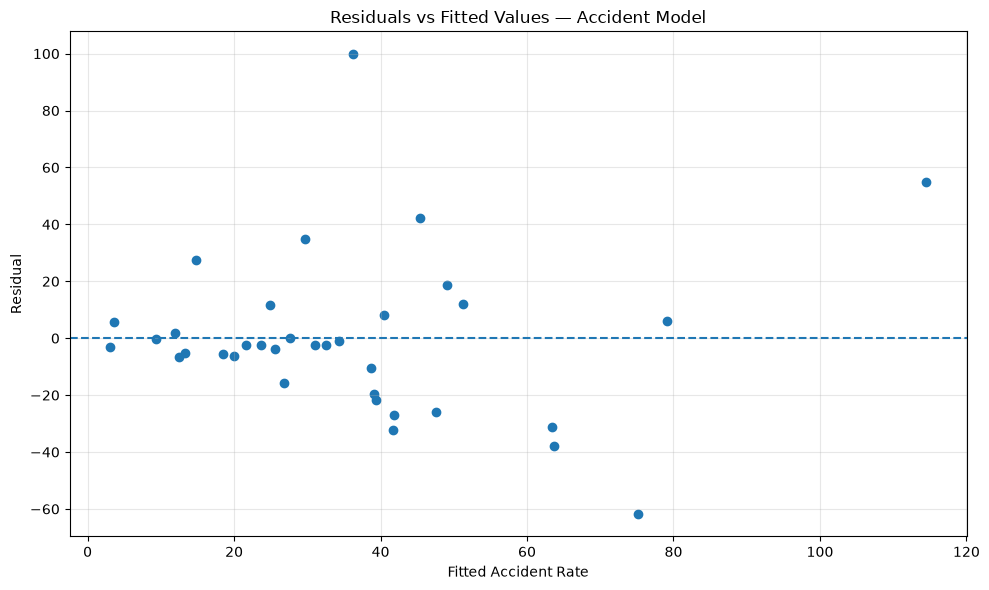

In [62]:
# Residual plot — Accident model

plt.figure(figsize=(10, 6))

plt.scatter(
    accident_model.fittedvalues,
    accident_model.resid
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fitted Accident Rate"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Fitted Values — Accident Model"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

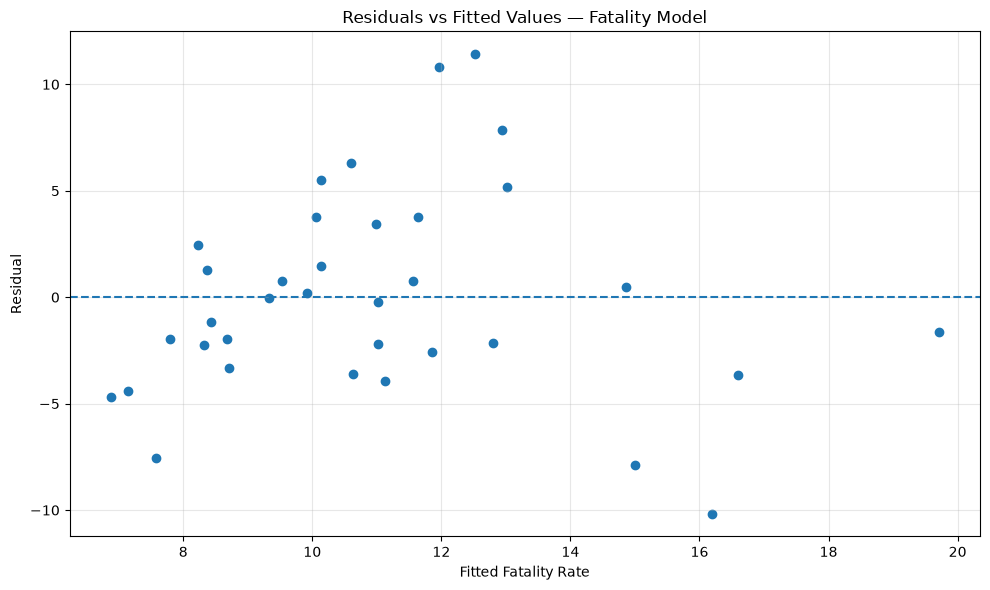

In [63]:
# Residual plot — Fatality model

plt.figure(figsize=(10, 6))

plt.scatter(
    fatality_model.fittedvalues,
    fatality_model.resid
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fitted Fatality Rate"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Fitted Values — Fatality Model"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [64]:
# Breusch-Pagan heteroskedasticity test

accident_bp = het_breuschpagan(
    accident_model.resid,
    accident_model.model.exog
)

fatality_bp = het_breuschpagan(
    fatality_model.resid,
    fatality_model.model.exog
)


print(
    "Accident model Breusch-Pagan p-value:",
    f"{accident_bp[1]:.6f}"
)

print(
    "Fatality model Breusch-Pagan p-value:",
    f"{fatality_bp[1]:.6f}"
)

Accident model Breusch-Pagan p-value: 0.142968
Fatality model Breusch-Pagan p-value: 0.146473


## Robust Standard Errors

Although the Breusch-Pagan tests do not provide evidence of
heteroskedasticity, the sample contains only 35 State/UT observations and
some observations are influential.

HC3 heteroskedasticity-robust standard errors are therefore used as a
conservative sensitivity check for coefficient inference.

The HC3 results are not used to change the fitted coefficients. They provide
more robust standard errors, t-statistics and p-values.

In [65]:
# HC3 robust results

accident_hc3 = (
    accident_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

fatality_hc3 = (
    fatality_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

In [66]:
# Helper function for HC3 results

def robust_result_table(model, robust_model):

    terms = model.model.exog_names

    return pd.DataFrame({
        "term": terms,
        "coefficient": robust_model.params,
        "HC3_std_error": robust_model.bse,
        "t_value": robust_model.tvalues,
        "p_value": robust_model.pvalues
    })


accident_hc3_table = robust_result_table(
    accident_model,
    accident_hc3
)

fatality_hc3_table = robust_result_table(
    fatality_model,
    fatality_hc3
)


print("ACCIDENT MODEL — HC3")

display(
    accident_hc3_table
)


print("\nFATALITY MODEL — HC3")

display(
    fatality_hc3_table
)

ACCIDENT MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,-17.536060,24.401104,-0.718658,0.477566
1,vehicles_per_1000_population,2.486362,1.115212,2.229498,0.032925
2,road_length_per_1000_population,-0.032321,1.126276,-0.028698,0.977284



FATALITY MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,5.527699,2.196097,2.517056,0.017039
1,vehicles_per_1000_population,0.292325,0.097441,3.000034,0.005194
2,road_length_per_1000_population,-0.117648,0.137085,-0.858217,0.397155


In [67]:
# HC3 confidence intervals

accident_ci = pd.DataFrame(
    accident_hc3.conf_int(),
    index=accident_model.model.exog_names,
    columns=[
        "lower_95",
        "upper_95"
    ]
)

fatality_ci = pd.DataFrame(
    fatality_hc3.conf_int(),
    index=fatality_model.model.exog_names,
    columns=[
        "lower_95",
        "upper_95"
    ]
)


print("Accident model HC3 confidence intervals:")

display(accident_ci)


print("\nFatality model HC3 confidence intervals:")

display(fatality_ci)

Accident model HC3 confidence intervals:


,lower_95,upper_95
const,-67.239484,32.167363
vehicles_per_1000_population,0.214750,4.757975
road_length_per_1000_population,-2.326471,2.261828



Fatality model HC3 confidence intervals:


,lower_95,upper_95
const,1.054396,10.001002
vehicles_per_1000_population,0.093845,0.490806
road_length_per_1000_population,-0.396880,0.161584


In [68]:
# Influence diagnostics

accident_influence = OLSInfluence(
    accident_model
)

fatality_influence = OLSInfluence(
    fatality_model
)


accident_cooks = (
    accident_influence
    .cooks_distance[0]
)

fatality_cooks = (
    fatality_influence
    .cooks_distance[0]
)

In [69]:
# Accident model influence


accident_influence_df = pd.DataFrame({

    "state": regression_df["state"],

    "cooks_distance": (
        accident_cooks
    ),

    "leverage": (
        accident_influence.hat_matrix_diag
    ),

    "standardized_residual": (
        accident_influence
        .resid_studentized_internal
    )
}).sort_values(
    "cooks_distance",
    ascending=False
)


display(
    accident_influence_df.head(10)
)

,state,cooks_distance,leverage,standardized_residual
5,Goa,1.320224,0.402960,2.422450
1,Arunachal Pradesh,0.579424,0.573320,-1.137396
29,Chandigarh,0.238236,0.124358,-2.243318
11,Kerala,0.117016,0.028660,3.449296
31,N.C.T of Delhi,0.061344,0.091916,-1.348388
7,Haryana,0.038567,0.084917,-1.116614
22,Tamil Nadu,0.030292,0.040398,1.469232
16,Mizoram,0.025857,0.057100,-1.131771
12,Madhya Pradesh,0.018579,0.036341,1.215713
32,Jammu & Kashmir,0.017890,0.054081,0.968877


In [70]:
# Fatality model influence

fatality_influence_df = pd.DataFrame({

    "state": regression_df["state"],

    "cooks_distance": (
        fatality_cooks
    ),

    "leverage": (
        fatality_influence.hat_matrix_diag
    ),

    "standardized_residual": (
        fatality_influence
        .resid_studentized_internal
    )
}).sort_values(
    "cooks_distance",
    ascending=False
)


display(
    fatality_influence_df.head(10)
)

,state,cooks_distance,leverage,standardized_residual
1,Arunachal Pradesh,0.246866,0.573320,0.742410
29,Chandigarh,0.221920,0.124358,-2.165141
34,Lakshadweep,0.094227,0.100375,-1.591724
31,N.C.T of Delhi,0.091379,0.091916,-1.645703
22,Tamil Nadu,0.075686,0.040398,2.322382
4,Chhattisgarh,0.062365,0.037444,2.193069
5,Goa,0.040211,0.402960,-0.422769
23,Telangana,0.039155,0.044010,1.597364
17,Nagaland,0.038494,0.117443,-0.931571
35,Puducherry,0.033071,0.139256,-0.783095


In [71]:
# Accident-model sensitivity analysis

def fit_accident_hc3(data):

    X = data[
        predictor_columns
    ]

    y = data[
        "accidents_per_100k_population"
    ]

    X = sm.add_constant(X)

    model = sm.OLS(
        y,
        X
    ).fit()

    return model.get_robustcov_results(
        cov_type="HC3"
    )


accident_full = fit_accident_hc3(
    regression_df
)

accident_no_goa = fit_accident_hc3(
    regression_df[
        regression_df["state"] != "Goa"
    ]
)

accident_no_goa_arunachal = fit_accident_hc3(
    regression_df[
        ~regression_df["state"].isin(
            [
                "Goa",
                "Arunachal Pradesh"
            ]
        )
    ]
)

In [72]:
# Accident sensitivity results

accident_sensitivity = pd.DataFrame({

    "sample": [
        "Full sample",
        "Without Goa",
        "Without Goa + Arunachal Pradesh"
    ],

    "n": [
        len(regression_df),
        len(regression_df) - 1,
        len(regression_df) - 2
    ],

    "vehicle_coefficient": [
        accident_full.params[1],
        accident_no_goa.params[1],
        accident_no_goa_arunachal.params[1]
    ],

    "vehicle_p_value": [
        accident_full.pvalues[1],
        accident_no_goa.pvalues[1],
        accident_no_goa_arunachal.pvalues[1]
    ],

    "road_coefficient": [
        accident_full.params[2],
        accident_no_goa.params[2],
        accident_no_goa_arunachal.params[2]
    ],

    "road_p_value": [
        accident_full.pvalues[2],
        accident_no_goa.pvalues[2],
        accident_no_goa_arunachal.pvalues[2]
    ]
})


display(
    accident_sensitivity
)

,sample,n,vehicle_coefficient,vehicle_p_value,road_coefficient,road_p_value
0,Full sample,35,2.486362,0.032925,-0.032321,0.977284
1,Without Goa,34,1.465829,0.035713,-0.453361,0.276976
2,Without Goa + Arunachal Pradesh,33,1.539218,0.036537,-0.152708,0.841840


In [73]:
# Fatality-model sensitivity analysis

def fit_fatality_hc3(data):

    X = data[
        predictor_columns
    ]

    y = data[
        "fatalities_per_100k_population"
    ]

    X = sm.add_constant(X)

    model = sm.OLS(
        y,
        X
    ).fit()

    return model.get_robustcov_results(
        cov_type="HC3"
    )


fatality_full = fit_fatality_hc3(
    regression_df
)

fatality_no_goa = fit_fatality_hc3(
    regression_df[
        regression_df["state"] != "Goa"
    ]
)

fatality_no_goa_arunachal = fit_fatality_hc3(
    regression_df[
        ~regression_df["state"].isin(
            [
                "Goa",
                "Arunachal Pradesh"
            ]
        )
    ]
)

In [74]:
# Fatality sensitivity results

fatality_sensitivity = pd.DataFrame({

    "sample": [
        "Full sample",
        "Without Goa",
        "Without Goa + Arunachal Pradesh"
    ],

    "n": [
        len(regression_df),
        len(regression_df) - 1,
        len(regression_df) - 2
    ],

    "vehicle_coefficient": [
        fatality_full.params[1],
        fatality_no_goa.params[1],
        fatality_no_goa_arunachal.params[1]
    ],

    "vehicle_p_value": [
        fatality_full.pvalues[1],
        fatality_no_goa.pvalues[1],
        fatality_no_goa_arunachal.pvalues[1]
    ],

    "road_coefficient": [
        fatality_full.params[2],
        fatality_no_goa.params[2],
        fatality_no_goa_arunachal.params[2]
    ],

    "road_p_value": [
        fatality_full.pvalues[2],
        fatality_no_goa.pvalues[2],
        fatality_no_goa_arunachal.pvalues[2]
    ]
})


display(
    fatality_sensitivity
)

,sample,n,vehicle_coefficient,vehicle_p_value,road_coefficient,road_p_value
0,Full sample,35,0.292325,0.005194,-0.117648,0.397155
1,Without Goa,34,0.322763,0.054681,-0.105091,0.424386
2,Without Goa + Arunachal Pradesh,33,0.296606,0.088353,-0.212249,0.216058


## Log-Transformed Outcome Models

The accident-rate distribution is positively skewed and the accident model
contains highly influential observations.

As a robustness check, the outcomes are therefore transformed using the
natural logarithm.

This does not replace the original model. It tests whether the conclusions
are sensitive to the functional form of the outcome.

The log transformation compresses very large State/UT outcome values and
allows us to assess whether the main associations remain similar under
another reasonable specification.

In [75]:
# Create log-transformed outcomes

regression_df["log_accident_rate"] = np.log(
    regression_df[
        "accidents_per_100k_population"
    ]
)

regression_df["log_fatality_rate"] = np.log(
    regression_df[
        "fatalities_per_100k_population"
    ]
)

print("Log-transformed outcomes created.")

Log-transformed outcomes created.


d:\Data Science\Projects\RoadSafe-India\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\Data Science\Projects\RoadSafe-India\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [76]:
# Log accident-rate model

X_log_accident = regression_df[
    predictor_columns
].copy()

X_log_accident = sm.add_constant(
    X_log_accident
)

y_log_accident = regression_df[
    "log_accident_rate"
]

log_accident_model = sm.OLS(
    y_log_accident,
    X_log_accident
).fit()

print(
    "Log accident model fitted successfully."
)

Log accident model fitted successfully.


In [77]:
# Log fatality-rate model

X_log_fatality = regression_df[
    predictor_columns
].copy()

X_log_fatality = sm.add_constant(
    X_log_fatality
)

y_log_fatality = regression_df[
    "log_fatality_rate"
]

log_fatality_model = sm.OLS(
    y_log_fatality,
    X_log_fatality
).fit()

print(
    "Log fatality model fitted successfully."
)

Log fatality model fitted successfully.


In [78]:
# Log-model fit statistics

log_model_fit = pd.DataFrame({

    "model": [
        "Log accident rate",
        "Log fatality rate"
    ],

    "R_squared": [
        log_accident_model.rsquared,
        log_fatality_model.rsquared
    ],

    "Adjusted_R_squared": [
        log_accident_model.rsquared_adj,
        log_fatality_model.rsquared_adj
    ]
})

display(
    log_model_fit
)

d:\Data Science\Projects\RoadSafe-India\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:466: RuntimeWarning: invalid value encountered in dot
  return np.dot(exog, params)
d:\Data Science\Projects\RoadSafe-India\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1970: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean) ** 2)


,model,R_squared,Adjusted_R_squared
0,Log accident rate,NaN,NaN
1,Log fatality rate,NaN,NaN


In [79]:
# HC3 robust results for log models

log_accident_hc3 = (
    log_accident_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

log_fatality_hc3 = (
    log_fatality_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

In [80]:
# Log-model HC3 coefficient tables

log_accident_hc3_table = robust_result_table(
    log_accident_model,
    log_accident_hc3
)

log_fatality_hc3_table = robust_result_table(
    log_fatality_model,
    log_fatality_hc3
)


print("LOG ACCIDENT MODEL — HC3")

display(
    log_accident_hc3_table
)


print("\nLOG FATALITY MODEL — HC3")

display(
    log_fatality_hc3_table
)

LOG ACCIDENT MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,-inf,NaN,NaN,NaN
1,vehicles_per_1000_population,inf,NaN,NaN,NaN
2,road_length_per_1000_population,inf,NaN,NaN,NaN



LOG FATALITY MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,-inf,NaN,NaN,NaN
1,vehicles_per_1000_population,inf,NaN,NaN,NaN
2,road_length_per_1000_population,inf,NaN,NaN,NaN


In [81]:
# -------------------------------------------------------
# Diagnose non-finite values before log transformation
# -------------------------------------------------------

print("Accident rate summary:")
print(
    regression_df[
        "accidents_per_100k_population"
    ].describe()
)

print("\nFatality rate summary:")
print(
    regression_df[
        "fatalities_per_100k_population"
    ].describe()
)


print("\nNon-positive accident rates:")
display(
    regression_df[
        regression_df[
            "accidents_per_100k_population"
        ] <= 0
    ][
        [
            "state",
            "accidents_per_100k_population"
        ]
    ]
)


print("\nNon-positive fatality rates:")
display(
    regression_df[
        regression_df[
            "fatalities_per_100k_population"
        ] <= 0
    ][
        [
            "state",
            "fatalities_per_100k_population"
        ]
    ]
)


print("\nNon-finite accident rates:")
print(
    (~np.isfinite(
        regression_df[
            "accidents_per_100k_population"
        ]
    )).sum()
)


print("\nNon-finite fatality rates:")
print(
    (~np.isfinite(
        regression_df[
            "fatalities_per_100k_population"
        ]
    )).sum()
)

Accident rate summary:
count     35.000000
mean      35.747632
std       36.665950
min        0.000000
25%       13.679139
50%       21.771576
75%       39.527929
max      169.425142
Name: accidents_per_100k_population, dtype: float64

Fatality rate summary:
count    35.000000
mean     11.005836
std       5.655555
min       0.000000
25%       7.068139
50%      10.294522
75%      14.866597
max      23.932079
Name: fatalities_per_100k_population, dtype: float64

Non-positive accident rates:


,state,accidents_per_100k_population
34,Lakshadweep,0.0



Non-positive fatality rates:


,state,fatalities_per_100k_population
34,Lakshadweep,0.0



Non-finite accident rates:
0

Non-finite fatality rates:
0


In [82]:
# -------------------------------------------------------
# Remove previous invalid log columns
# -------------------------------------------------------

regression_df = regression_df.drop(
    columns=[
        "log_accident_rate",
        "log_fatality_rate"
    ],
    errors="ignore"
)

In [83]:
# -------------------------------------------------------
# Create sample for log-transformed models
# -------------------------------------------------------

log_regression_df = regression_df[
    (
        regression_df["accidents_per_100k_population"] > 0
    )
    &
    (
        regression_df["fatalities_per_100k_population"] > 0
    )
].copy()


print(
    "Original regression observations:",
    len(regression_df)
)

print(
    "Log-model observations:",
    len(log_regression_df)
)

print("\nExcluded States:")
print(
    sorted(
        set(regression_df["state"])
        - set(log_regression_df["state"])
    )
)

Original regression observations: 35
Log-model observations: 34

Excluded States:
['Lakshadweep']


In [84]:
# -------------------------------------------------------
# Create log-transformed outcomes
# -------------------------------------------------------

log_regression_df["log_accident_rate"] = np.log(
    log_regression_df[
        "accidents_per_100k_population"
    ]
)

log_regression_df["log_fatality_rate"] = np.log(
    log_regression_df[
        "fatalities_per_100k_population"
    ]
)


print("Log outcomes created successfully.")

print(
    "\nNon-finite log accident values:",
    (~np.isfinite(
        log_regression_df["log_accident_rate"]
    )).sum()
)

print(
    "Non-finite log fatality values:",
    (~np.isfinite(
        log_regression_df["log_fatality_rate"]
    )).sum()
)

Log outcomes created successfully.

Non-finite log accident values: 0
Non-finite log fatality values: 0


In [85]:
# -------------------------------------------------------
# Log accident-rate model
# -------------------------------------------------------

X_log_accident = log_regression_df[
    predictor_columns
].copy()

X_log_accident = sm.add_constant(
    X_log_accident
)

y_log_accident = log_regression_df[
    "log_accident_rate"
]

log_accident_model = sm.OLS(
    y_log_accident,
    X_log_accident
).fit()

print(
    "Log accident model fitted successfully."
)

Log accident model fitted successfully.


In [86]:
# -------------------------------------------------------
# Log fatality-rate model
# -------------------------------------------------------

X_log_fatality = log_regression_df[
    predictor_columns
].copy()

X_log_fatality = sm.add_constant(
    X_log_fatality
)

y_log_fatality = log_regression_df[
    "log_fatality_rate"
]

log_fatality_model = sm.OLS(
    y_log_fatality,
    X_log_fatality
).fit()

print(
    "Log fatality model fitted successfully."
)

Log fatality model fitted successfully.


In [87]:
# -------------------------------------------------------
# HC3 robust inference
# -------------------------------------------------------

log_accident_hc3 = (
    log_accident_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

log_fatality_hc3 = (
    log_fatality_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

In [88]:
# -------------------------------------------------------
# Log-model HC3 results
# -------------------------------------------------------

log_accident_hc3_table = pd.DataFrame({
    "term": log_accident_model.model.exog_names,
    "coefficient": log_accident_hc3.params,
    "HC3_std_error": log_accident_hc3.bse,
    "t_value": log_accident_hc3.tvalues,
    "p_value": log_accident_hc3.pvalues
})

log_fatality_hc3_table = pd.DataFrame({
    "term": log_fatality_model.model.exog_names,
    "coefficient": log_fatality_hc3.params,
    "HC3_std_error": log_fatality_hc3.bse,
    "t_value": log_fatality_hc3.tvalues,
    "p_value": log_fatality_hc3.pvalues
})


print("LOG ACCIDENT MODEL — HC3")
display(log_accident_hc3_table)

print("\nLOG FATALITY MODEL — HC3")
display(log_fatality_hc3_table)

LOG ACCIDENT MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,2.237036,0.299897,7.459340,2.104707e-08
1,vehicles_per_1000_population,0.051477,0.014060,3.661349,9.270883e-04
2,road_length_per_1000_population,-0.016588,0.011968,-1.386035,1.756264e-01



LOG FATALITY MODEL — HC3


,term,coefficient,HC3_std_error,t_value,p_value
0,const,1.814068,0.277782,6.530546,2.737664e-07
1,vehicles_per_1000_population,0.027021,0.010907,2.477357,1.889237e-02
2,road_length_per_1000_population,-0.014835,0.022322,-0.664578,5.112339e-01


In [89]:
print(
    "Log accident R²:",
    round(log_accident_model.rsquared, 4)
)

print(
    "Log accident adjusted R²:",
    round(log_accident_model.rsquared_adj, 4)
)

print(
    "\nLog fatality R²:",
    round(log_fatality_model.rsquared, 4)
)

print(
    "Log fatality adjusted R²:",
    round(log_fatality_model.rsquared_adj, 4)
)

Log accident R²: 0.3563
Log accident adjusted R²: 0.3147

Log fatality R²: 0.2592
Log fatality adjusted R²: 0.2114


## Log-Transformation Data Handling

Lakshadweep has zero reported accidents and zero reported fatalities in
the 2024 dataset, resulting in zero population-normalized accident and
fatality rates.

Because the natural logarithm of zero is undefined, Lakshadweep is excluded
from the log-transformed sensitivity models.

The original non-logarithmic regression models retain Lakshadweep.

No value is imputed and no artificial constant is added to the outcome.

In [90]:
# Influence diagnostics — log accident model

log_accident_influence = OLSInfluence(
    log_accident_model
)

log_accident_cooks = (
    log_accident_influence
    .cooks_distance[0]
)

log_accident_influence_df = pd.DataFrame({

    "state": regression_df["state"],

    "cooks_distance": (
        log_accident_cooks
    )

}).sort_values(
    "cooks_distance",
    ascending=False
)

display(
    log_accident_influence_df.head(10)
)

,state,cooks_distance
29,Chandigarh,0.266677
5,Goa,0.110236
17,Nagaland,0.078132
11,Kerala,0.062465
16,Mizoram,0.046590
32,Jammu & Kashmir,0.044984
31,N.C.T of Delhi,0.033320
12,Madhya Pradesh,0.031192
22,Tamil Nadu,0.030855
30,Dadra & Nagar Haveli and Daman & Diu,0.026388


In [91]:
# Influence diagnostics — log fatality model

log_fatality_influence = OLSInfluence(
    log_fatality_model
)

log_fatality_cooks = (
    log_fatality_influence
    .cooks_distance[0]
)

log_fatality_influence_df = pd.DataFrame({

    "state": regression_df["state"],

    "cooks_distance": (
        log_fatality_cooks
    )

}).sort_values(
    "cooks_distance",
    ascending=False
)

display(
    log_fatality_influence_df.head(10)
)

,state,cooks_distance
1,Arunachal Pradesh,0.911972
29,Chandigarh,0.234146
14,Manipur,0.206894
17,Nagaland,0.173944
31,N.C.T of Delhi,0.083905
5,Goa,0.061861
22,Tamil Nadu,0.034047
4,Chhattisgarh,0.031948
0,Andhra Pradesh,0.021589
23,Telangana,0.021065


In [92]:
# Compare original and log models

model_comparison = pd.DataFrame({

    "model": [
        "Accident rate",
        "Log accident rate",
        "Fatality rate",
        "Log fatality rate"
    ],

    "R_squared": [
        accident_model.rsquared,
        log_accident_model.rsquared,
        fatality_model.rsquared,
        log_fatality_model.rsquared
    ],

    "Adjusted_R_squared": [
        accident_model.rsquared_adj,
        log_accident_model.rsquared_adj,
        fatality_model.rsquared_adj,
        log_fatality_model.rsquared_adj
    ]
})


display(
    model_comparison
)

,model,R_squared,Adjusted_R_squared
0,Accident rate,0.396962,0.359272
1,Log accident rate,0.356260,0.314729
2,Fatality rate,0.259728,0.213461
3,Log fatality rate,0.259226,0.211434


In [93]:
# Final coefficient comparison

final_model_results = pd.DataFrame({

    "model": [
        "Accident rate",
        "Log accident rate",
        "Fatality rate",
        "Log fatality rate"
    ],

    "vehicle_coefficient": [
        accident_hc3.params[1],
        log_accident_hc3.params[1],
        fatality_hc3.params[1],
        log_fatality_hc3.params[1]
    ],

    "vehicle_p_value_HC3": [
        accident_hc3.pvalues[1],
        log_accident_hc3.pvalues[1],
        fatality_hc3.pvalues[1],
        log_fatality_hc3.pvalues[1]
    ],

    "road_coefficient": [
        accident_hc3.params[2],
        log_accident_hc3.params[2],
        fatality_hc3.params[2],
        log_fatality_hc3.params[2]
    ],

    "road_p_value_HC3": [
        accident_hc3.pvalues[2],
        log_accident_hc3.pvalues[2],
        fatality_hc3.pvalues[2],
        log_fatality_hc3.pvalues[2]
    ]
})


display(
    final_model_results
)

,model,vehicle_coefficient,vehicle_p_value_HC3,road_coefficient,road_p_value_HC3
0,Accident rate,2.486362,0.032925,-0.032321,0.977284
1,Log accident rate,0.051477,0.000927,-0.016588,0.175626
2,Fatality rate,0.292325,0.005194,-0.117648,0.397155
3,Log fatality rate,0.027021,0.018892,-0.014835,0.511234


In [94]:
# -------------------------------------------------------
# Save regression results
# -------------------------------------------------------

results_path = (
    project_root
    / "data"
    / "research"
    / "multivariable_regression_results.csv"
)

final_model_results.to_csv(
    results_path,
    index=False
)

print(
    "Regression results saved to:"
)

print(results_path)

Regression results saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\multivariable_regression_results.csv


## Preliminary Interpretation

### Accident Burden

The multivariable model examines whether vehicle exposure and normalized
road infrastructure are associated with population-normalized reported
accident burden.

The vehicle-exposure coefficient is evaluated using HC3 robust standard
errors and sensitivity analyses involving influential State/UT observations.

### Fatality Burden

The fatality model evaluates whether vehicle exposure and normalized road
infrastructure are associated with population-normalized reported fatality
burden.

The stability of the vehicle coefficient is assessed using influential-
observation sensitivity analysis and an alternative log-transformed outcome
specification.

### Road Infrastructure

The available evidence for normalized road length is evaluated separately
from vehicle exposure. The 2019 road-length measurement is interpreted as a
lagged structural indicator rather than a 2024 exposure measure.

### Caution

The models are exploratory, observational and based on only 35 complete
State/UT observations. Estimated associations do not establish causality.

In [95]:
# -------------------------------------------------------
# Cook's distance — Log Accident Model
# -------------------------------------------------------

log_accident_influence = OLSInfluence(
    log_accident_model
)

log_accident_cooks = (
    log_accident_influence
    .cooks_distance[0]
)

log_accident_influence_df = pd.DataFrame({
    "state": regression_df.loc[
        log_regression_df.index,
        "state"
    ],
    "cooks_distance": log_accident_cooks
}).sort_values(
    "cooks_distance",
    ascending=False
)

display(
    log_accident_influence_df.head(10)
)

,state,cooks_distance
29,Chandigarh,0.266677
5,Goa,0.110236
17,Nagaland,0.078132
11,Kerala,0.062465
16,Mizoram,0.046590
32,Jammu & Kashmir,0.044984
31,N.C.T of Delhi,0.033320
12,Madhya Pradesh,0.031192
22,Tamil Nadu,0.030855
30,Dadra & Nagar Haveli and Daman & Diu,0.026388


In [96]:
# -------------------------------------------------------
# Cook's distance — Log Fatality Model
# -------------------------------------------------------

log_fatality_influence = OLSInfluence(
    log_fatality_model
)

log_fatality_cooks = (
    log_fatality_influence
    .cooks_distance[0]
)

log_fatality_influence_df = pd.DataFrame({
    "state": log_regression_df.loc[
        log_fatality_model.model.data.row_labels,
        "state"
    ],
    "cooks_distance": log_fatality_cooks
}).sort_values(
    "cooks_distance",
    ascending=False
)

display(
    log_fatality_influence_df.head(10)
)

,state,cooks_distance
1,Arunachal Pradesh,0.911972
29,Chandigarh,0.234146
14,Manipur,0.206894
17,Nagaland,0.173944
31,N.C.T of Delhi,0.083905
5,Goa,0.061861
22,Tamil Nadu,0.034047
4,Chhattisgarh,0.031948
0,Andhra Pradesh,0.021589
23,Telangana,0.021065


In [98]:
# -------------------------------------------------------
# Final regression summary
# -------------------------------------------------------

final_regression_summary = pd.DataFrame({

    "model": [
        "Accident rate — OLS HC3",
        "Accident rate — Log OLS HC3",
        "Fatality rate — OLS HC3",
        "Fatality rate — Log OLS HC3"
    ],

    "observations": [
        len(regression_df),
        len(log_regression_df),
        len(regression_df),
        len(log_regression_df)
    ],

    "r_squared": [
        accident_model.rsquared,
        log_accident_model.rsquared,
        fatality_model.rsquared,
        log_fatality_model.rsquared
    ],

    "adjusted_r_squared": [
        accident_model.rsquared_adj,
        log_accident_model.rsquared_adj,
        fatality_model.rsquared_adj,
        log_fatality_model.rsquared_adj
    ],

    "vehicle_coefficient": [
        accident_hc3.params[1],
        log_accident_hc3.params[1],
        fatality_hc3.params[1],
        log_fatality_hc3.params[1]
    ],

    "vehicle_p_value_HC3": [
        accident_hc3.pvalues[1],
        log_accident_hc3.pvalues[1],
        fatality_hc3.pvalues[1],
        log_fatality_hc3.pvalues[1]
    ],

    "road_coefficient": [
        accident_hc3.params[2],
        log_accident_hc3.params[2],
        fatality_hc3.params[2],
        log_fatality_hc3.params[2]
    ],

    "road_p_value_HC3": [
        accident_hc3.pvalues[2],
        log_accident_hc3.pvalues[2],
        fatality_hc3.pvalues[2],
        log_fatality_hc3.pvalues[2]
    ]
})

display(final_regression_summary)

,model,observations,r_squared,adjusted_r_squared,vehicle_coefficient,vehicle_p_value_HC3,road_coefficient,road_p_value_HC3
0,Accident rate — OLS HC3,35,0.396962,0.359272,2.486362,0.032925,-0.032321,0.977284
1,Accident rate — Log OLS HC3,34,0.356260,0.314729,0.051477,0.000927,-0.016588,0.175626
2,Fatality rate — OLS HC3,35,0.259728,0.213461,0.292325,0.005194,-0.117648,0.397155
3,Fatality rate — Log OLS HC3,34,0.259226,0.211434,0.027021,0.018892,-0.014835,0.511234


In [99]:
results_path = (
    project_root
    / "data"
    / "research"
    / "final_regression_summary.csv"
)

final_regression_summary.to_csv(
    results_path,
    index=False
)

print("Saved to:")
print(results_path)

Saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\final_regression_summary.csv


## Final Regression Findings

### Accident Burden

Vehicle exposure is positively associated with population-normalized
reported accident burden.

The association remains statistically significant in both the original
accident-rate model and the log-transformed accident-rate model using HC3
robust standard errors.

The log transformation substantially reduces the influence of Goa, which is
highly influential in the original accident-rate specification.

### Fatality Burden

Vehicle exposure is positively associated with population-normalized
reported fatality burden in both the original and log-transformed models.

However, the fatality model remains more sensitive to influential
observations, particularly Arunachal Pradesh. Therefore, the fatality
association should be interpreted more cautiously.

### Road Infrastructure

Population-normalized road length does not show statistically significant
evidence of association with population-normalized accident or fatality
burden in the current sample.

### Overall Conclusion

The analysis provides evidence of a consistent positive association between
vehicle ownership and State/UT-level road-safety burden, particularly for
reported accidents.

The evidence does not establish causation. Vehicle registrations are an
exposure proxy, road infrastructure is measured using 2019 data, and the
analysis is based on a relatively small number of aggregated State/UT
observations.